In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st 

df = pd.read_csv("UAC.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,21-Dec-25,6,18,11,"2,484",14
1,18-Dec-25,11,50,6,"2,472",16
2,17-Dec-25,7,31,11,"2,481",10
3,16-Dec-25,8,54,15,"2,468",9
4,15-Dec-25,11,42,9,"2,470",7


In [2]:
df.shape

(720, 6)

In [3]:
df.isnull().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [4]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [5]:
df.columns.tolist()


['Date',
 'Children apprehended and placed in CBP custody*',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

In [6]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [7]:
df.isnull().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [8]:
df.columns.tolist()

['Date',
 'Children apprehended and placed in CBP custody*',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].head())
print(df.shape)

0   2023-01-12
1   2023-01-22
2   2023-01-23
3   2023-01-24
4   2023-01-25
Name: Date, dtype: datetime64[us]
(720, 6)


In [10]:
#plt.figure(figsize=(12,5))
#plt.plot(df["Date"], df["HHS_Care"], color="blue", linewidth=1.5)
#plt.title("Children in HHS Care Over Time")
#plt.xlabel("Date")
#plt.ylabel("Count")
#plt.show()

In [11]:
df = pd.read_csv("UAC.csv")
df.columns = ["Date","CBP_Apprehended","CBP_Custody",
              "CBP_Transferred","HHS_Care","HHS_Discharged"]
df.columns = df.columns.str.strip()
df = df.dropna(subset=["Date"])
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
print("Done!")
print(df.columns.tolist())
print(df.shape)

Done!
['Date', 'CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 'HHS_Care', 'HHS_Discharged']
(720, 6)


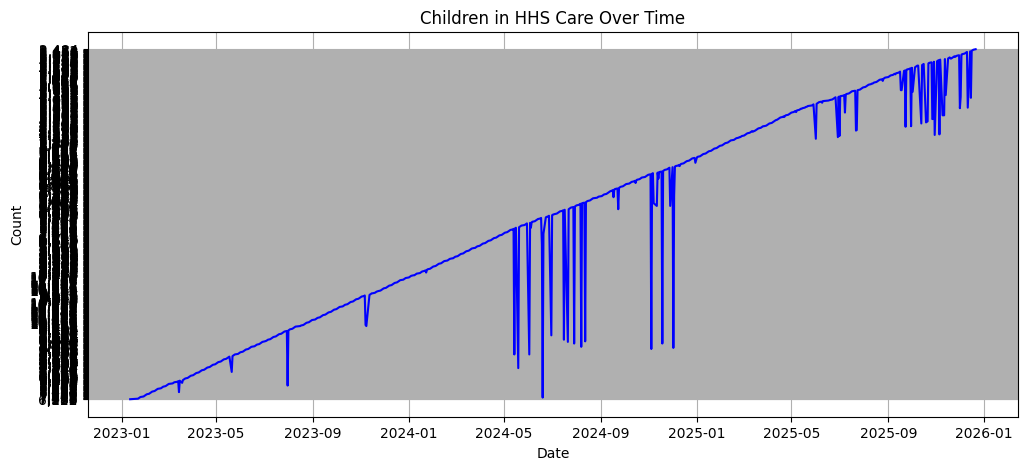

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["HHS_Care"], color="blue", linewidth=1.5)
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.show()

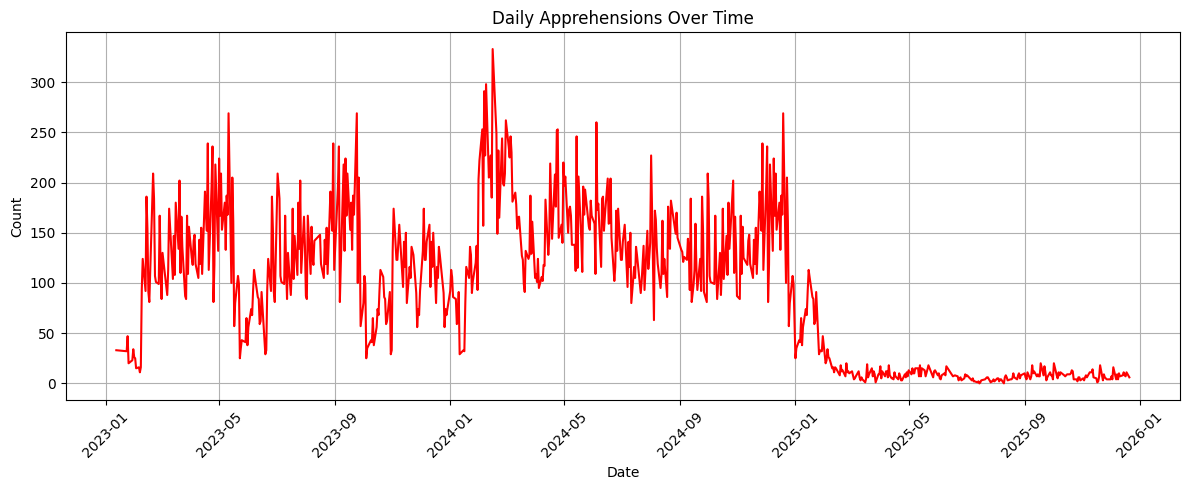

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["CBP_Apprehended"], color="red", linewidth=1.5)
plt.title("Daily Apprehensions Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

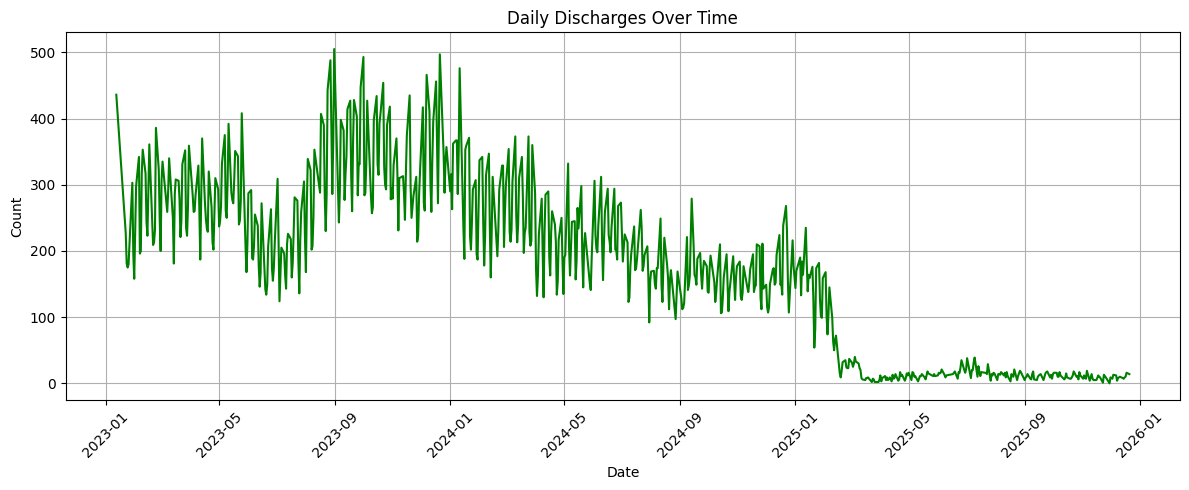

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["HHS_Discharged"], color="green", linewidth=1.5)
plt.title("Daily Discharges Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

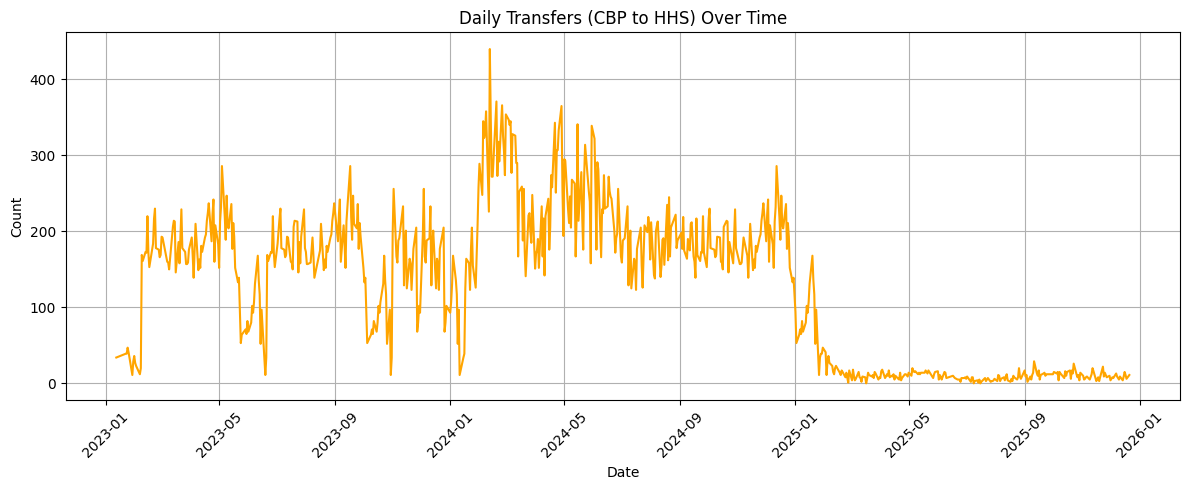

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["CBP_Transferred"], color="orange", linewidth=1.5)
plt.title("Daily Transfers (CBP to HHS) Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

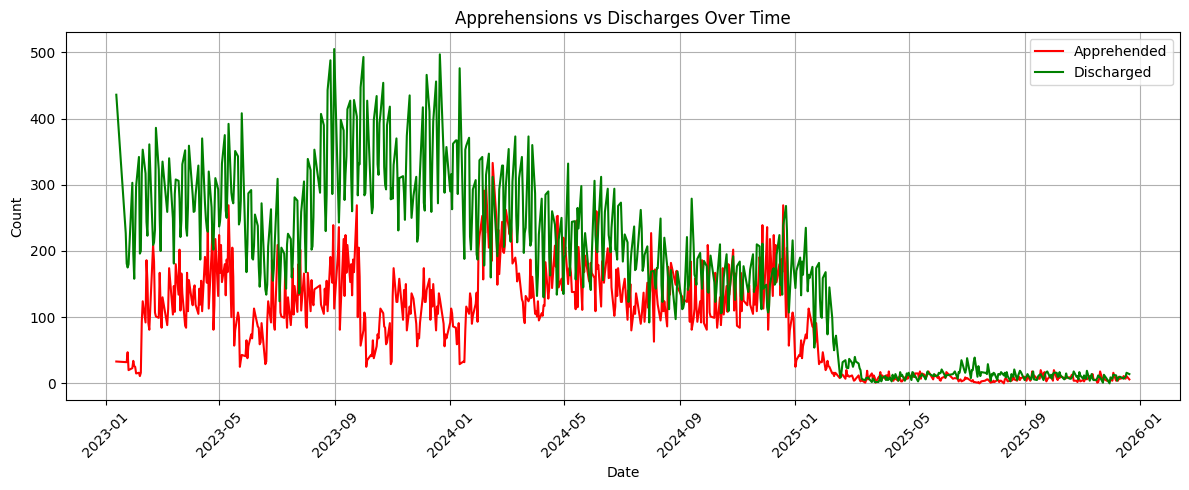

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["CBP_Apprehended"], color="red", linewidth=1.5, label="Apprehended")
plt.plot(df["Date"], df["HHS_Discharged"], color="green", linewidth=1.5, label="Discharged")
plt.title("Apprehensions vs Discharges Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
df.shape
df.head(3)

,Date,CBP_Apprehended,CBP_Custody,CBP_Transferred,HHS_Care,HHS_Discharged
0,2023-01-12,33,53,34,"6,566",436
1,2023-01-22,32,49,39,"7,122",227
2,2023-01-23,32,50,39,"7,280",181


In [18]:
# KPI Calculation
df["CBP_Apprehended"] = pd.to_numeric(df["CBP_Apprehended"], errors="coerce").fillna(0)
df["CBP_Transferred"] = pd.to_numeric(df["CBP_Transferred"], errors="coerce").fillna(0)
df["HHS_Care"] = pd.to_numeric(df["HHS_Care"], errors="coerce").fillna(0)
df["HHS_Discharged"] = pd.to_numeric(df["HHS_Discharged"], errors="coerce").fillna(0)

df["Transfer_Efficiency"] = df["CBP_Transferred"] / df["CBP_Apprehended"].replace(0, 1)
df["Discharge_Effectiveness"] = df["HHS_Discharged"] / df["HHS_Care"].replace(0, 1) * 100
df["Pipeline_Throughput"] = (df["CBP_Transferred"] + df["HHS_Discharged"]) / (df["CBP_Apprehended"] + df["CBP_Transferred"]).replace(0, 1)

print("KPI Calculated!")
print(df.shape)
print(df[["Date","Transfer_Efficiency","Discharge_Effectiveness","Pipeline_Throughput"]].head(10))

KPI Calculated!
(720, 9)
        Date  Transfer_Efficiency  Discharge_Effectiveness  \
0 2023-01-12             1.030303                  43600.0   
1 2023-01-22             1.218750                  22700.0   
2 2023-01-23             1.218750                  18100.0   
3 2023-01-24             1.000000                  17500.0   
4 2023-01-25             2.050000                  18000.0   
5 2023-01-29             0.478261                  30300.0   
6 2023-01-30             0.852941                  19600.0   
7 2023-01-31             1.384615                  15800.0   
8 2023-02-01             1.080000                  23100.0   
9 2023-02-02             1.533333                  29800.0   

   Pipeline_Throughput  
0             7.014925  
1             3.746479  
2             3.098592  
3             2.361702  
4             3.622951  
5             9.235294  
6             3.571429  
7             3.129032  
8             4.961538  
9             8.447368  


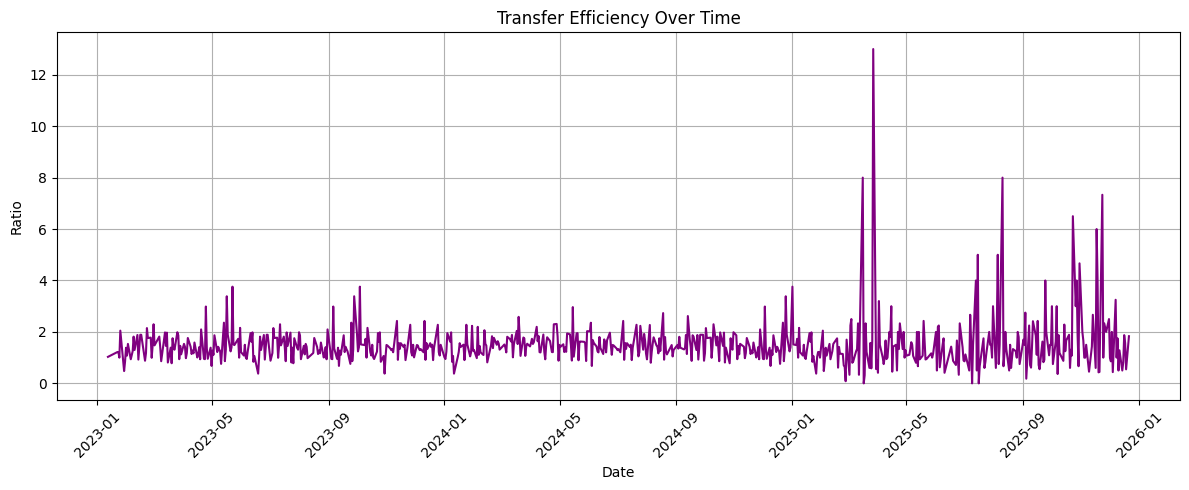

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Transfer_Efficiency"], color="purple", linewidth=1.5)
plt.title("Transfer Efficiency Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


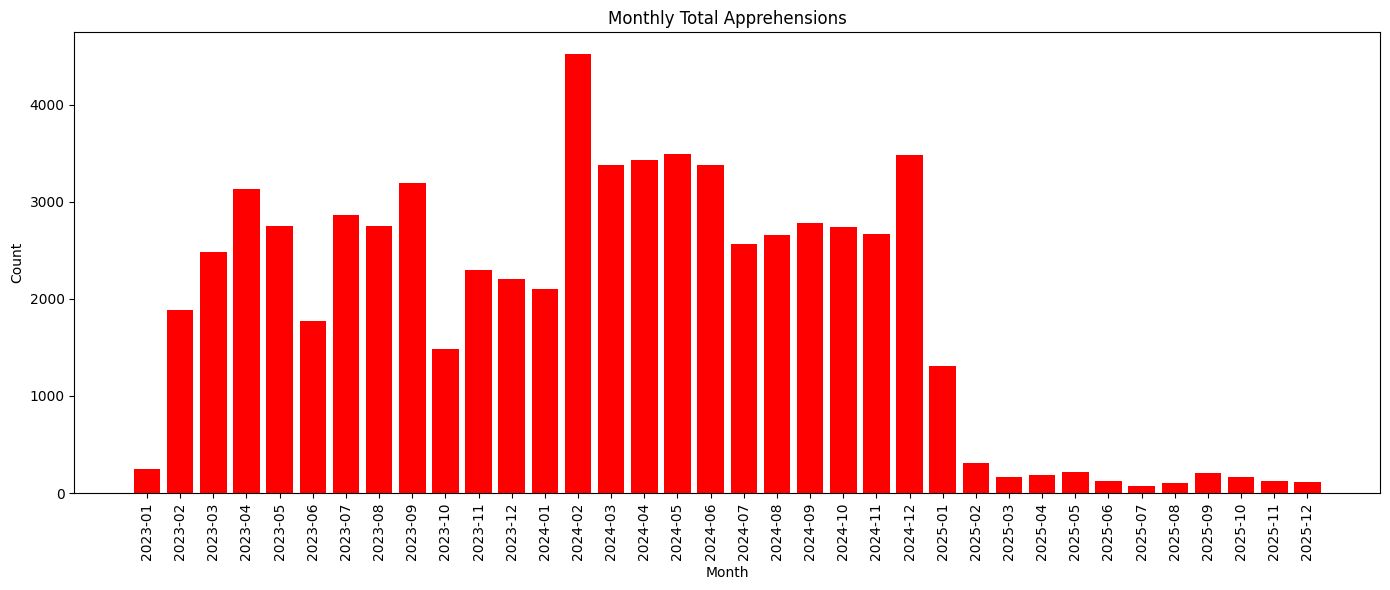

In [20]:
# Monthly average bar chart
df["Month"] = df["Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Month")["CBP_Apprehended"].sum().reset_index()

plt.figure(figsize=(14,6))
plt.bar(monthly["Month"], monthly["CBP_Apprehended"], color="red")
plt.title("Monthly Total Apprehensions")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

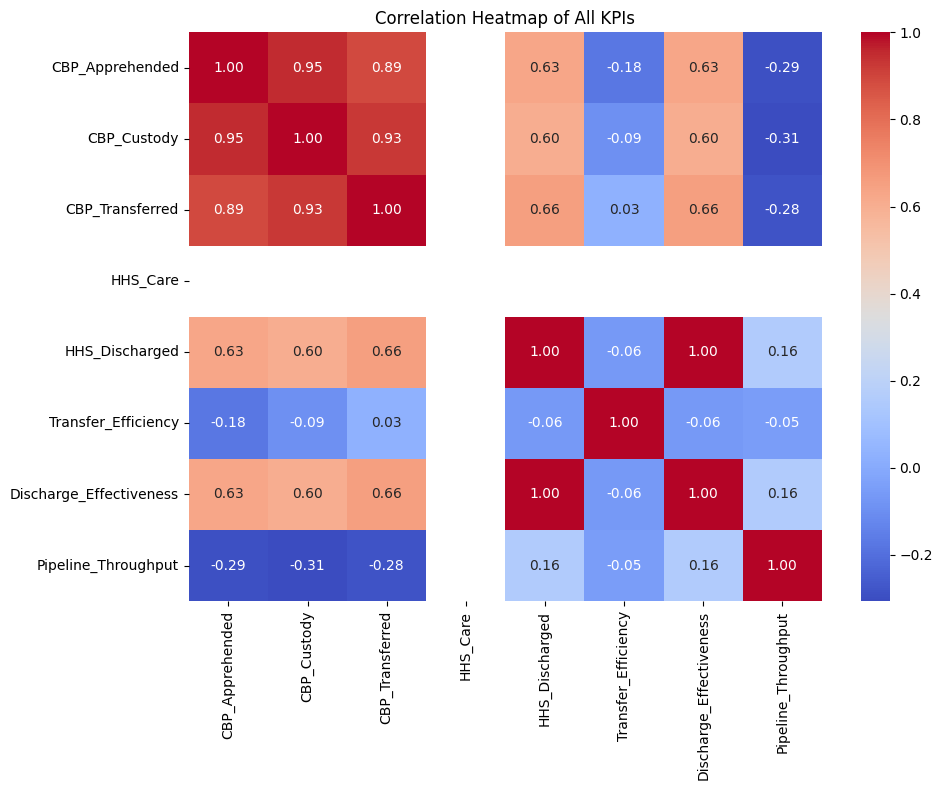

In [21]:
# Heatmap
import seaborn as sns

corr = df[["CBP_Apprehended","CBP_Custody","CBP_Transferred",
           "HHS_Care","HHS_Discharged",
           "Transfer_Efficiency","Discharge_Effectiveness",
           "Pipeline_Throughput"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of All KPIs")
plt.tight_layout()
plt.show()

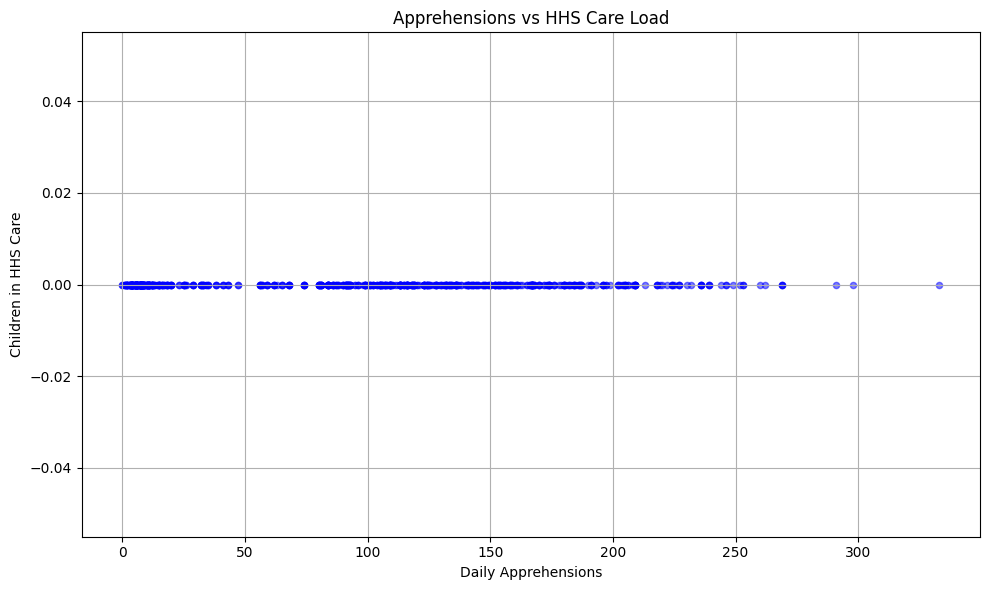

In [23]:
# Scatter Chart
plt.figure(figsize=(10,6))
plt.scatter(df["CBP_Apprehended"], df["HHS_Care"].astype(float), 
            color="blue", alpha=0.5, s=20)
plt.title("Apprehensions vs HHS Care Load")
plt.xlabel("Daily Apprehensions")
plt.ylabel("Children in HHS Care")
plt.grid(True)
plt.tight_layout()
plt.show()

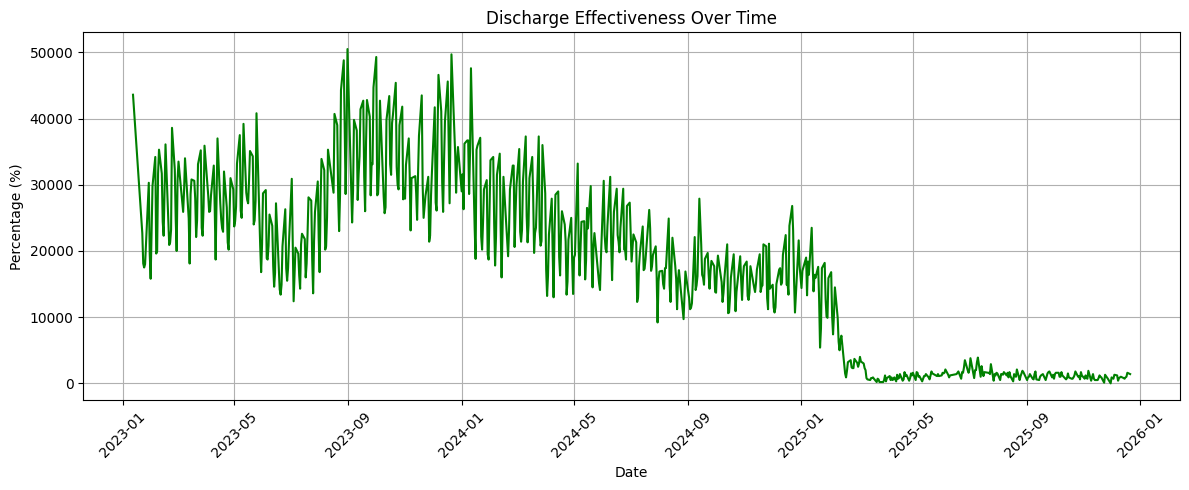

In [24]:
# Discharge Effectiveness over time
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Discharge_Effectiveness"], 
         color="green", linewidth=1.5)
plt.title("Discharge Effectiveness Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()